<a href="https://colab.research.google.com/github/wetherc/data-2000/blob/sp26/labs/071_convolutional-networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Assignment: Image Classification with Convolutional Neural Networks (CNNs)

## Objective
In this lab, you will build, train, and evaluate a Convolutional Neural Network (CNN) to classify images of pets. 🐶🐱

## Dataset
We will be using the **Oxford-IIIT Pet** (`oxford_iiit_pet`) dataset, which contains images of 37 different pet breeds (cats and dogs). Image classification on this dataset is an excellent way to practice CNNs due to the variety of breeds and variations in image composition.

## Instructions
1. Run the provided starter code to download and load the dataset.
2. Design and compile a CNN architecture.
3. Train your model and plot the learning curves (loss and accuracy).
4. Evaluate the model on the validation/test set and discuss your findings.

### Part 1: Environment Setup and Data Loading
The following cell imports the necessary libraries and loads the dataset using TensorFlow Datasets (`tfds`). We will use the predefined `train` split for our training dataset and the `test` split for our validation dataset.

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

tf.random.set_seed(42)

(train_ds, val_ds), ds_info = tfds.load(
    'oxford_iiit_pet',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True,
)

print("Dataset Information:")
print(f"Number of training examples: {ds_info.splits['train'].num_examples}")
print(f"Number of validation examples: {ds_info.splits['test'].num_examples}")
print(f"Number of classes: {ds_info.features['label'].num_classes}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.BER71W_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.BER71W_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Dataset Information:
Number of training examples: 3680
Number of validation examples: 3669
Number of classes: 37


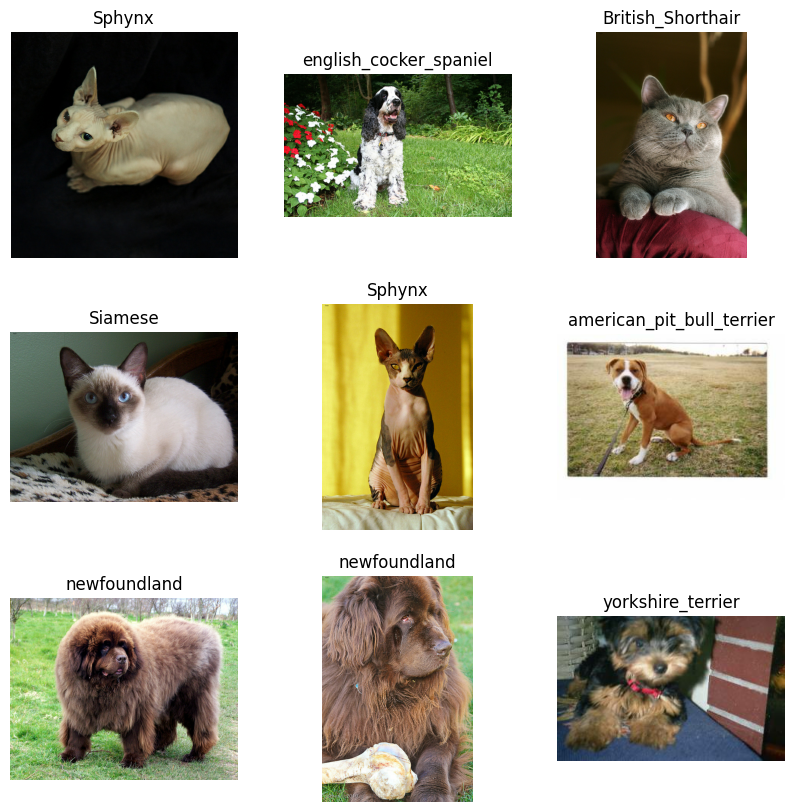

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
# train_ds is not batched yet, so we take 9 individual examples
for i, (image, label) in enumerate(train_ds.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image.numpy().astype("uint8"))
    # Use ds_info to get the string representation of the label
    plt.title(ds_info.features['label'].int2str(label.numpy()))
    plt.axis("off")

### Part 2: Data Preprocessing & Augmentation

Here, we'll write a function to preprocess the images. Specifically, we will:
1. Resize all images to a uniform size (e.g., $250 \times 250$).
2. Apply the mapping function to `train_ds` and `val_ds`.
3. Shuffle and batch the training dataset. Batch the validation dataset.

Note that the images in this dataset are actually of varying dimensions. We will need to standardize them prior to modeling because neural networks (especially the fully connected layers) expect fixed-size inputs, and TensorFlow requires all tensors in a batch to have the exact same shape.

In [3]:
# Let's check the shapes of the first few images
for image, label in train_ds.take(3):
    print(f"Image shape: {image.shape}")

Image shape: (500, 500, 3)
Image shape: (313, 500, 3)
Image shape: (500, 333, 3)


In [4]:
IMG_SIZE = 250
BATCH_SIZE = 32

def preprocess_image(image, label):
    # Resize image to a uniform size
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

# Apply preprocessing, shuffle, and batch the training dataset
train_ds = train_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

# Apply preprocessing and batch the validation dataset
val_ds = val_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

### Part 3: Building the CNN Model
**Task:** Design a Convolutional Neural Network using the Keras Functional API. Your model should include:
- A Rescaling layer to normalize pixel values (`tf.keras.layers.Rescaling(1./255)`)
- Image augmentation layers of your choosing
- Convolutional layers (`Conv2D`)
- Pooling layers (`MaxPooling2D`)
- A Flatten layer
- Dense layers (`Dense`)
- Dropout layers for regularization (`Dropout`)

Compile the model using an appropriate loss function (e.g., `sparse_categorical_crossentropy`), optimizer (e.g., `adam`, `RMSprop`), and metric (`sparse_categorical_accuracy`).

In [6]:
num_classes = ds_info.features['label'].num_classes

img_input = tf.keras.layers.Input(shape=[250, 250, 3])

augmented_input = tf.keras.layers.RandomFlip("horizontal", input_shape=(250, 250, 3))(img_input)
augmented_input = tf.keras.layers.RandomRotation(0.1)(augmented_input)
augmented_input = tf.keras.layers.RandomZoom(0.1)(augmented_input)

rescaled = tf.keras.layers.Rescaling(1./255)(augmented_input)

conv1 = tf.keras.layers.Conv2D(
    filters=16,
    kernel_size=4,
    activation="relu",
)(rescaled)
conv1 = tf.keras.layers.AveragePooling2D(2)(conv1)

conv2 = tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=4,
    activation="relu",
)(conv1)
conv2 = tf.keras.layers.AveragePooling2D(2)(conv2)

conv3 = tf.keras.layers.Conv2D(
    filters=64,
    kernel_size=4,
    activation="relu",
)(conv2)
conv3 = tf.keras.layers.AveragePooling2D(2)(conv3)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
flattened = tf.keras.layers.Flatten()(conv3)
dropout = tf.keras.layers.Dropout(0.5)(flattened)

dense1 = tf.keras.layers.Dense(256, activation="relu")(dropout)
dense2 = tf.keras.layers.Dense(128, activation="relu")(dense1)

# num_classes = 37 pet species
output = tf.keras.layers.Dense(num_classes, activation="softmax")(dense2)

In [8]:
model = tf.keras.Model(img_input, output)

In [9]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 250, 250, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 250, 250, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 250, 250, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 250, 250, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 250, 250, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 247, 247, 16)   │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 123, 123, 16)   │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 120, 120, 32)   │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 60, 60, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 57, 57, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 28, 28, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,924,821 (49.30 MB)

 Trainable params: 12,924,821 (49.30 MB)

 Non-trainable params: 0 (0.00 B)

### Part 4: Model Training & Evaluation
**Task:**
1. Train the model using `model.fit()` for a reasonable number of epochs (e.g., 20). Be sure to use an early stopping callback
2. Plot the training and validation accuracy over epochs.
3. Plot the training and validation loss over epochs.
4. Briefly discuss your results. Did the model overfit? How could it be improved?

In [ ]:
# TODO: Train the model and plot the learning curves